# Описание проекта

Интернет-магазин «В один клик» предлагает широкий ассортимент товаров: товары для детей, дома, мелкую бытовую технику, косметику и продукты. Анализ отчётов за прошлый период показал снижение покупательской активности клиентов. Привлечение новых пользователей перестало быть эффективным, так как большая часть целевой аудитории уже знакома с магазином. В связи с этим компания принимает стратегическое решение сосредоточиться на удержании постоянных клиентов.

Одним из способов повышения покупательской активности является внедрение персонализированных предложений. Руководство компании придерживается data-driven подхода и принимает решения исключительно на основе анализа данных и бизнес-моделирования. Для реализации данной задачи привлекается отдел цифровых технологий, в рамках которого необходимо разработать аналитическое решение.

# Цель проекта
 Построить модель машинного обучения, способную предсказать вероятность снижения покупательской активности клиента в ближайшие три месяца, а также на основе результатов моделирования и данных о прибыльности клиентов выполнить сегментацию покупателей и предложить персонализированные меры по увеличению их активности.
 
# Шаги к выполнению проекта

### Загрузка данных

- Загрузка всех предоставленных таблиц.
- Проверка корректности форматов, разделителей и соответствия описанию.

### Предобработка данных

- Приведение типов данных.
- Обработка пропусков и дубликатов.
- Приведение числовых значений к корректному формату.

### Исследовательский анализ данных (EDA)

- Анализ каждой таблицы отдельно.
- Изучение распределений признаков и целевого показателя.
- Отбор клиентов с покупательской активностью не менее трёх месяцев.

### Объединение таблиц

- Объединение таблиц с поведением, выручкой и временем на сайте.
- Преобразование данных о периодах в отдельные признаки.

### Корреляционный анализ

- Анализ корреляций между количественными признаками.
- Выявление и устранение мультиколлинеарности при необходимости.

### Построение моделей

- Подготовка данных с использованием Pipeline и ColumnTransformer.
- Раздельная обработка числовых и категориальных признаков.
- Обучение моделей:

    - KNeighborsClassifier
    - DecisionTreeClassifier
    - LogisticRegression
    - SVC

- Подбор гиперпараметров.
- Выбор основной метрики качества и сравнение моделей.
### Анализ важности признаков

- Оценка влияния признаков на предсказания лучшей модели.
- Использование SHAP для интерпретации результатов.
- Формирование выводов для бизнеса.

### Сегментация покупателей

- Расчёт вероятности снижения активности для клиентов.
- Добавление данных о прибыльности.
- Выделение клиентских сегментов.
- Анализ выбранного сегмента и разработка персонализированных предложений.

### Общий вывод

- Краткое описание задачи и подхода.
- Итоги моделирования и выбор лучшей модели.
- Выводы по сегментации.
- Практические рекомендации для бизнеса.

# Загрузка данных

Импорт всех необходимых для работы библиотек

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_curve

from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

Чтение и вывод датасетов, первоначальный анализ

In [3]:
path_market_file = "/datasets/market_file.csv"
path_market_money = "/datasets/market_money.csv"
path_market_time = "/datasets/market_time.csv"
path_money = "/datasets/money.csv"

market_file = pd.read_csv(path_market_file)
market_money = pd.read_csv(path_market_money)
market_time = pd.read_csv(path_market_time)

# разделитель
money = pd.read_csv(path_money, sep=';')

display(market_file.head())
display(market_money.head())
display(market_time.head())
display(money.head())

print(market_file.shape, market_money.shape, market_time.shape, money.shape)
market_file.info()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


,id,Прибыль
0,215348,"0,98"
1,215349,"4,16"
2,215350,"3,13"
3,215351,"4,87"
4,215352,"4,21"


(1300, 13) (3900, 3) (2600, 3) (1300, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   in

Данные обладают хорошим качеством и полнотой, позволяют описать поведение клиентов с точки зрения коммуникаций, вовлечённости, продуктового и финансового поведения.
Наличие временных признаков (выручка и время по месяцам) и данных о прибыльности делает возможным не только построение предиктивной модели, но и бизнес-ориентированную сегментацию клиентов для разработки персонализированных предложений.

# Предобработка данных


исправления форматов и опечаток

In [4]:
market_time["Период"] = market_time["Период"].replace({"предыдцщий_месяц": "предыдущий_месяц"})

money["Прибыль"] = money["Прибыль"].astype(str).str.replace(",", ".", regex=False).astype(float)

for name, df in [("market_file", market_file), ("market_money", market_money), ("market_time", market_time), ("money", money)]:
    print("\n", name)
    print("duplicates:", df.duplicated().sum())
    print("nulls:\n", df.isna().sum())

print("\nПериоды market_money:", market_money["Период"].unique())
print("Периоды market_time :", market_time["Период"].unique())
print("\nПрибыль describe:")
display(money["Прибыль"].describe())


 market_file
duplicates: 0
nulls:
 id                                     0
Покупательская активность              0
Тип сервиса                            0
Разрешить сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
dtype: int64

 market_money
duplicates: 0
nulls:
 id         0
Период     0
Выручка    0
dtype: int64

 market_time
duplicates: 0
nulls:
 id        0
Период    0
минут     0
dtype: int64

 money
duplicates: 0
nulls:
 id         0
Прибыль    0
dtype: int64

Периоды market_money: ['препредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']
Периоды market_time : ['текущий_месяц' 'предыдущий_месяц']

Прибыль describe:


count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: Прибыль, dtype: float64

- Исправили опечатку периода в `market_time`, чтобы корректно развернуть данные по месяцам.
- Привели `Прибыль` к типу `float` (запятая → точка).
- Проверили пропуски и дубли. Пропуски будут обрабатываться в пайплайнах (импутация).

# Исследовательский анализ данных (EDA)

Удаляем 1 явную ошибку данных: max(Выручка) = 106862.2


,id,Период,Выручка
98,215380,текущий_месяц,106862.2


Размер до: (3900, 3) | после: (3899, 3)
Топ-5 выручек после удаления ошибки:


,id,Период,Выручка
435,215493,текущий_месяц,7799.4
262,215435,текущий_месяц,7605.3
1481,215841,текущий_месяц,7557.0
2388,216144,текущий_месяц,7547.8
566,215536,текущий_месяц,7467.9


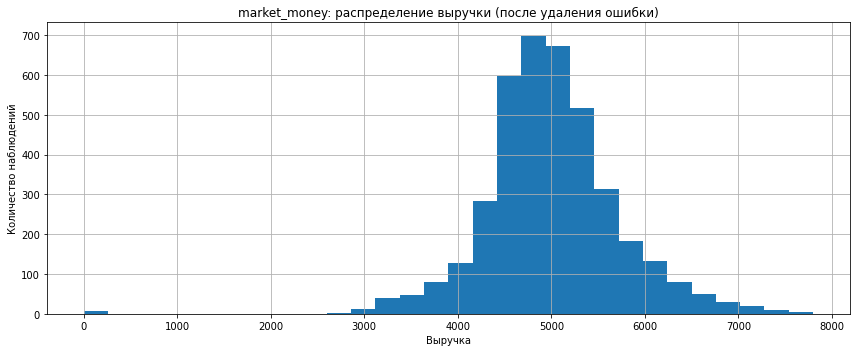

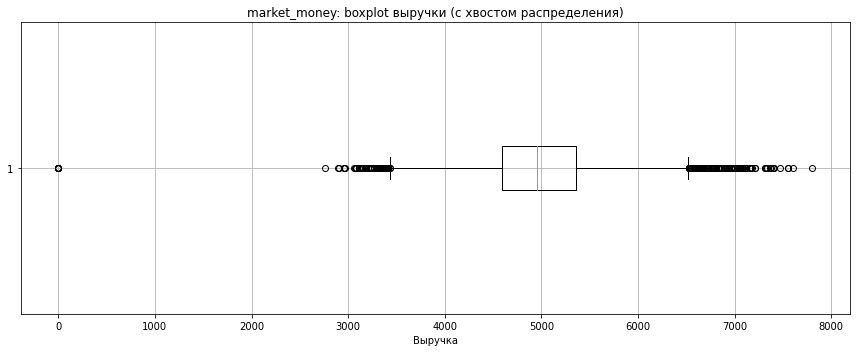

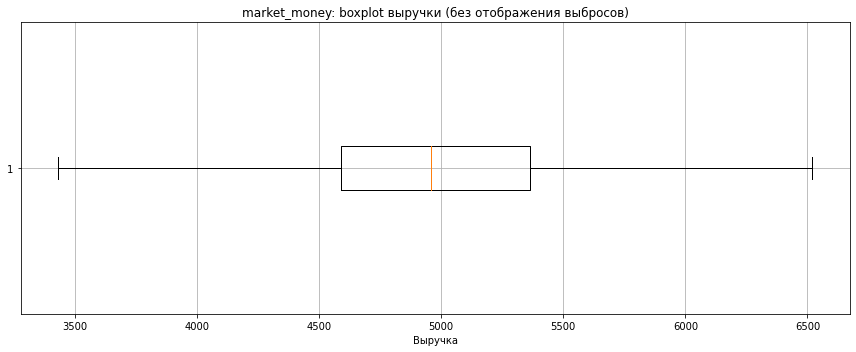

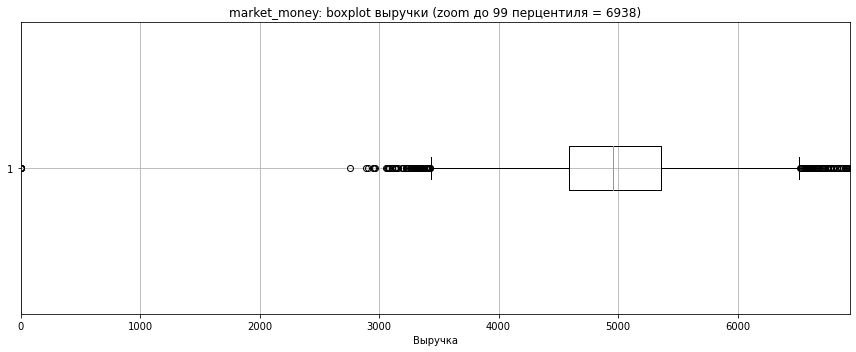

In [5]:
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

max_val = market_money["Выручка"].max()
anomaly_rows = market_money[market_money["Выручка"] == max_val][["id", "Период", "Выручка"]]

print(f"Удаляем 1 явную ошибку данных: max(Выручка) = {max_val}")
display(anomaly_rows)

market_money_clean = market_money[market_money["Выручка"] < max_val].copy()
print("Размер до:", market_money.shape, "| после:", market_money_clean.shape)

print("Топ-5 выручек после удаления ошибки:")
display(market_money_clean.sort_values("Выручка", ascending=False).head(5)[["id", "Период", "Выручка"]])

plt.figure()
plt.hist(market_money_clean["Выручка"], bins=30)
plt.title("market_money: распределение выручки (после удаления ошибки)")
plt.xlabel("Выручка")
plt.ylabel("Количество наблюдений")
plt.tight_layout()
plt.show()

plt.figure()
plt.boxplot(market_money_clean["Выручка"], vert=False)
plt.title("market_money: boxplot выручки (с хвостом распределения)")
plt.xlabel("Выручка")
plt.tight_layout()
plt.show()

plt.figure()
plt.boxplot(market_money_clean["Выручка"], vert=False, showfliers=False)
plt.title("market_money: boxplot выручки (без отображения выбросов)")
plt.xlabel("Выручка")
plt.tight_layout()
plt.show()

p99 = market_money_clean["Выручка"].quantile(0.99)

plt.figure()
plt.boxplot(market_money_clean["Выручка"], vert=False)
plt.xlim(0, p99)
plt.title(f"market_money: boxplot выручки (zoom до 99 перцентиля = {p99:.0f})")
plt.xlabel("Выручка")
plt.tight_layout()
plt.show()


Распределение выручки имеет асимметричный вид с выраженным правым хвостом, что характерно для финансовых показателей. Использование стандартных методов определения выбросов (IQR, квантили) в данном случае может приводить к ошибочной классификации крупных, но реальных покупок как аномалий.

В ходе анализа было выявлено одно экстремальное значение выручки — 106 862.2, существенно превышающее остальные наблюдения. При этом прибыль по данному `id` не отличается от прибыли других клиентов, что указывает на возможную ошибку в данных, а не на реальное аномальное поведение пользователя.

На основании этого было принято решение удалить **только одно явно ошибочное значение**, без применения агрессивной фильтрации хвостов распределения. Остальные значения выручки, включая крупные покупки, сохранены в данных как валидные наблюдения.


<div class="alert alert-info">
    <h2> Комментарий студента 2 <a class="tocSkip"></h2>
        
Исправил</div>

<div class="alert alert-info">
    <h2> Комментарий студента 4 <a class="tocSkip"></h2>
        
Добавил аргументацию, убрал выброс. Остальные данные входят в "</div>

market_time — пропуски:
 id        0
Период    0
минут     0
dtype: int64
market_time — дубликаты: 0


,id,минут
count,2600.000000,2600.000000
mean,215997.500000,13.336154
std,375.349754,4.080198
min,215348.000000,4.000000
25%,215672.750000,10.000000
50%,215997.500000,13.000000
75%,216322.250000,16.000000
max,216647.000000,23.000000


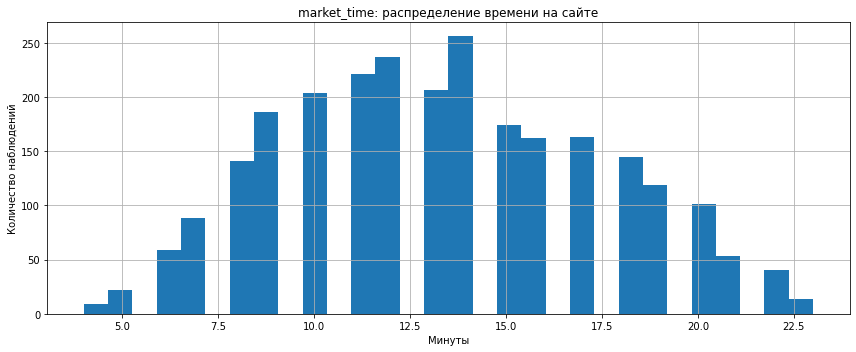

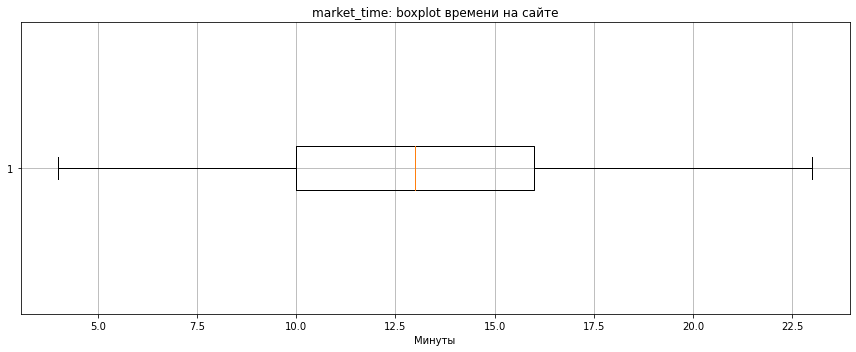

In [6]:

print("market_time — пропуски:\n", market_time.isna().sum())
print("market_time — дубликаты:", market_time.duplicated().sum())
display(market_time.describe())

# Гистограмма
plt.figure()
plt.hist(market_time["минут"], bins=30)
plt.title("market_time: распределение времени на сайте")
plt.xlabel("Минуты")
plt.ylabel("Количество наблюдений")
plt.tight_layout()
plt.show()

# Boxplot
plt.figure()
plt.boxplot(market_time["минут"], vert=False)
plt.title("market_time: boxplot времени на сайте")
plt.xlabel("Минуты")
plt.tight_layout()
plt.show()


money — пропуски:
 id         0
Прибыль    0
dtype: int64
money — дубликаты: 0


,id,Прибыль
count,1300.000000,1300.000000
mean,215997.500000,3.996631
std,375.421985,1.013722
min,215348.000000,0.860000
25%,215672.750000,3.300000
50%,215997.500000,4.045000
75%,216322.250000,4.670000
max,216647.000000,7.430000


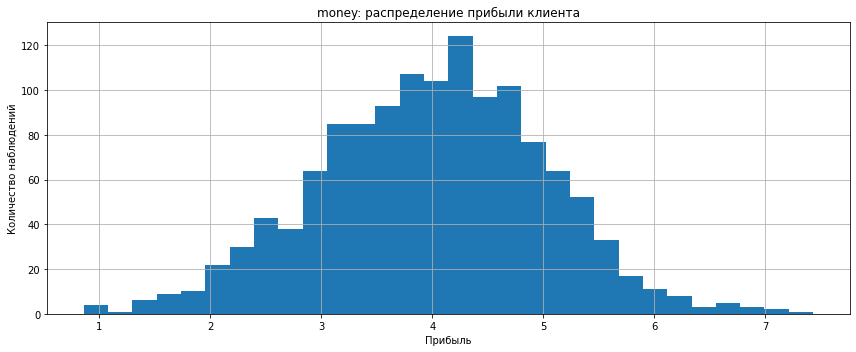

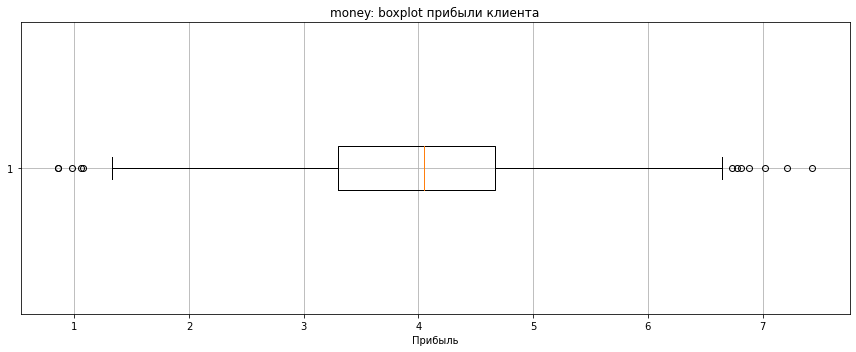

In [7]:
print("money — пропуски:\n", money.isna().sum())
print("money — дубликаты:", money.duplicated().sum())
display(money.describe())

# Гистограмма
plt.figure()
plt.hist(money["Прибыль"], bins=30)
plt.title("money: распределение прибыли клиента")
plt.xlabel("Прибыль")
plt.ylabel("Количество наблюдений")
plt.tight_layout()
plt.show()

# Boxplot
plt.figure()
plt.boxplot(money["Прибыль"], vert=False)
plt.title("money: boxplot прибыли клиента")
plt.xlabel("Прибыль")
plt.tight_layout()
plt.show()


Распределение прибыли является относительно симметричным и не содержит
экстремальных выбросов. Признак хорошо подходит для сегментации клиентов
и не требует дополнительной очистки.

In [8]:
anomaly_id = int(anomaly_rows["id"].iloc[0])

rev_pivot = market_money_clean.pivot_table(
    index="id",
    columns="Период",
    values="Выручка",
    aggfunc="sum"
).fillna(0)

# клиент активен, если выручка > 0 ровно в 3 месяцах
active_mask = (rev_pivot > 0).sum(axis=1) == 3
active_ids = rev_pivot.index[active_mask]

# исключаем клиента с аномалией целиком
active_ids = active_ids[active_ids != anomaly_id]

print("Уникальных клиентов всего:", rev_pivot.shape[0])
print("Активных клиентов (3 из 3 месяцев):", len(active_ids))
print("Исключено клиентов:", rev_pivot.shape[0] - len(active_ids))


Уникальных клиентов всего: 1300
Активных клиентов (3 из 3 месяцев): 1296
Исключено клиентов: 4


market_file — пропуски:
 id                                     0
Покупательская активность              0
Тип сервиса                            0
Разрешить сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
dtype: int64
market_file — дубликаты: 0


,count,mean,std,min,25%,50%,75%,max
id,1300.0,215997.500000,375.421985,215348.0,215672.75,215997.50,216322.25,216647.00
Маркет_актив_6_мес,1300.0,4.253769,1.014814,0.9,3.70,4.20,4.90,6.60
Маркет_актив_тек_мес,1300.0,4.011538,0.696868,3.0,4.00,4.00,4.00,5.00
Длительность,1300.0,601.898462,249.856289,110.0,405.50,606.00,806.00,1079.00
Акционные_покупки,1300.0,0.319808,0.249843,0.0,0.17,0.24,0.30,0.99
Средний_просмотр_категорий_за_визит,1300.0,3.270000,1.355350,1.0,2.00,3.00,4.00,6.00
Неоплаченные_продукты_штук_квартал,1300.0,2.840000,1.971451,0.0,1.00,3.00,4.00,10.00
Ошибка_сервиса,1300.0,4.185385,1.955298,0.0,3.00,4.00,6.00,9.00
Страниц_за_визит,1300.0,8.176923,3.978126,1.0,5.00,8.00,11.00,20.00


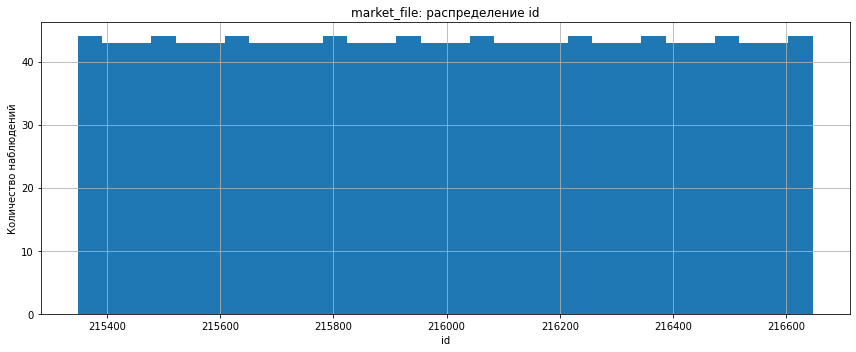

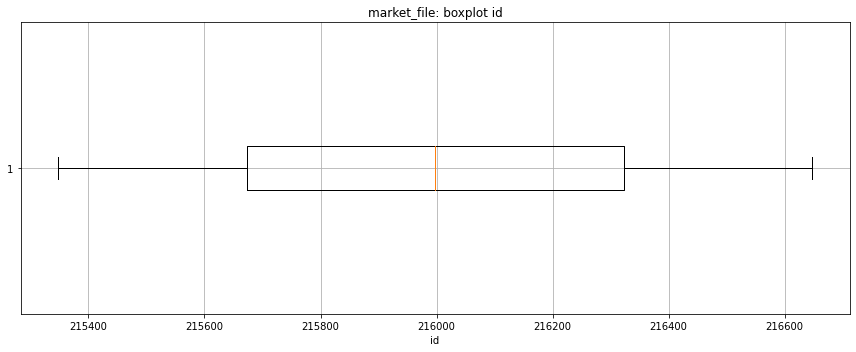

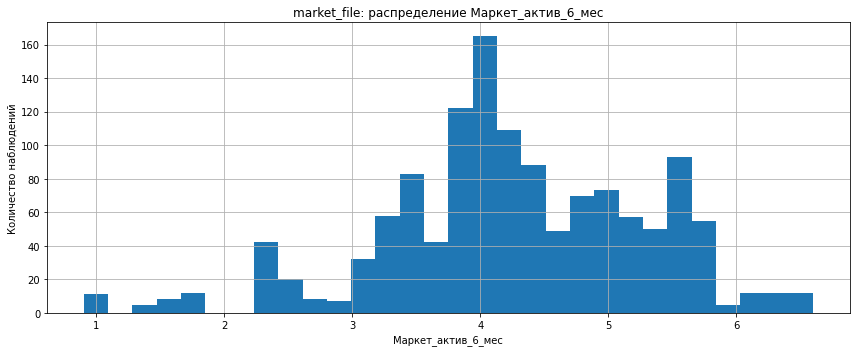

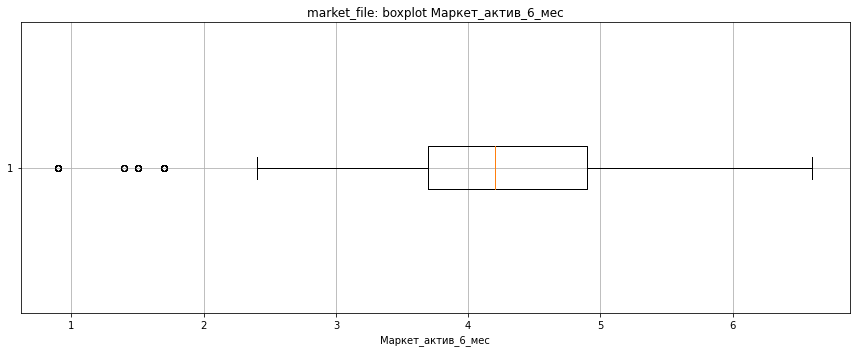

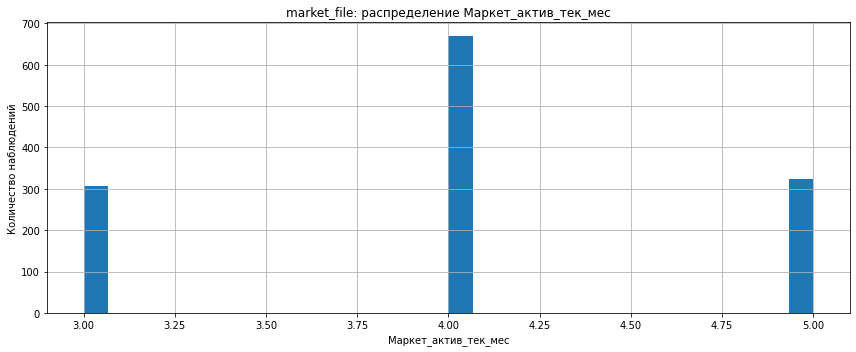

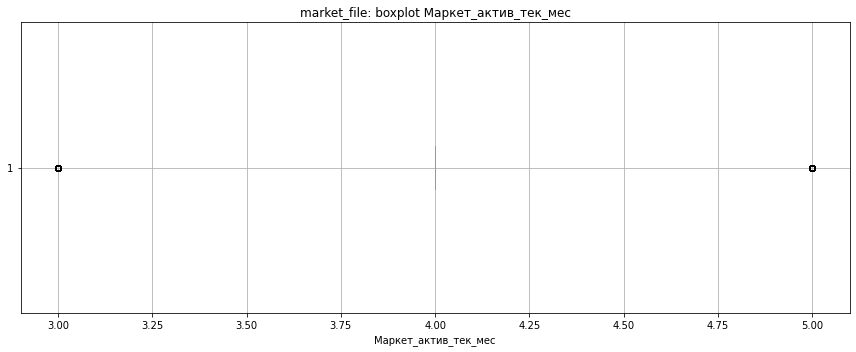

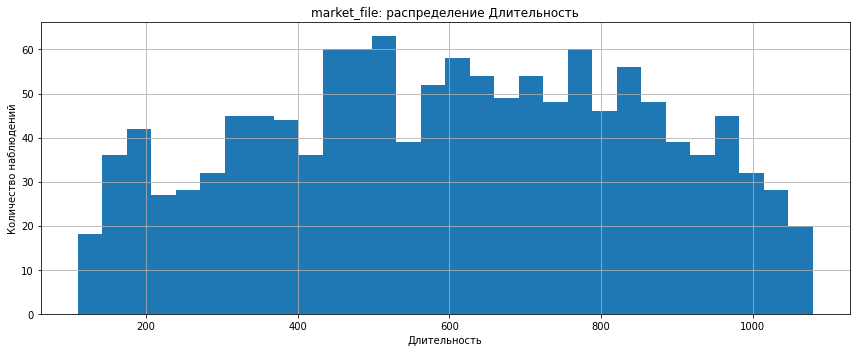

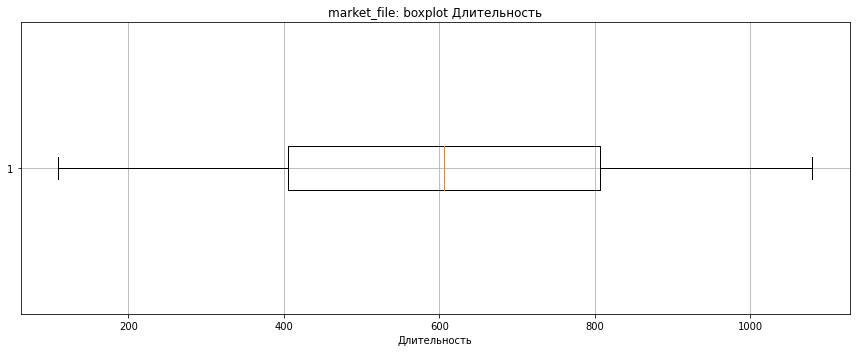

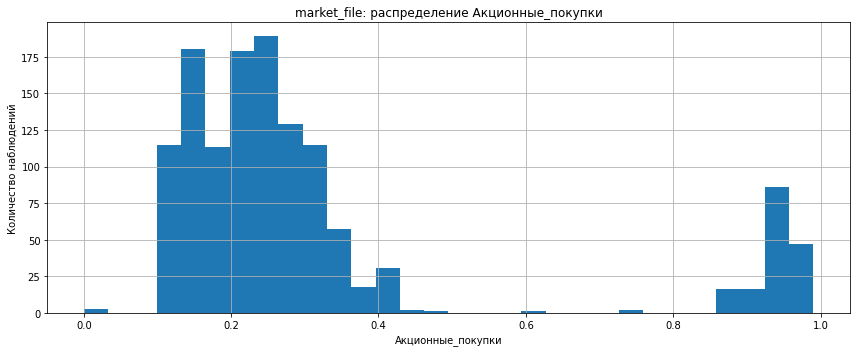

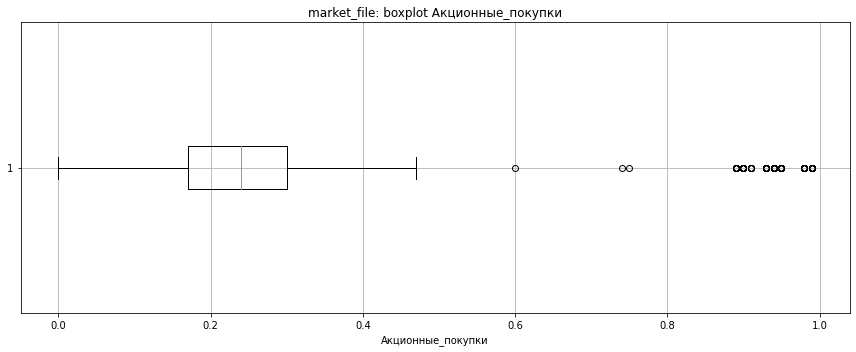

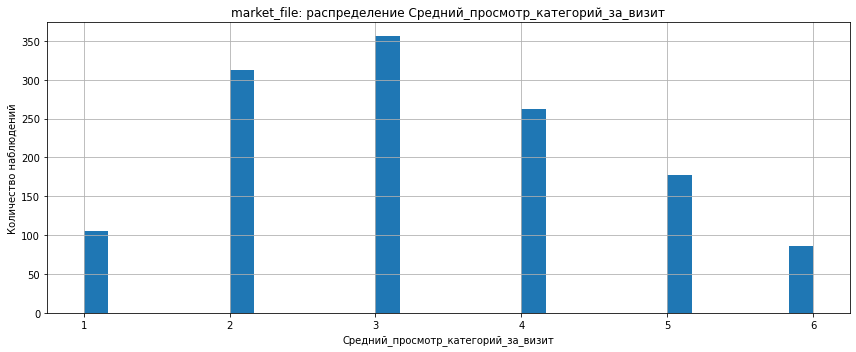

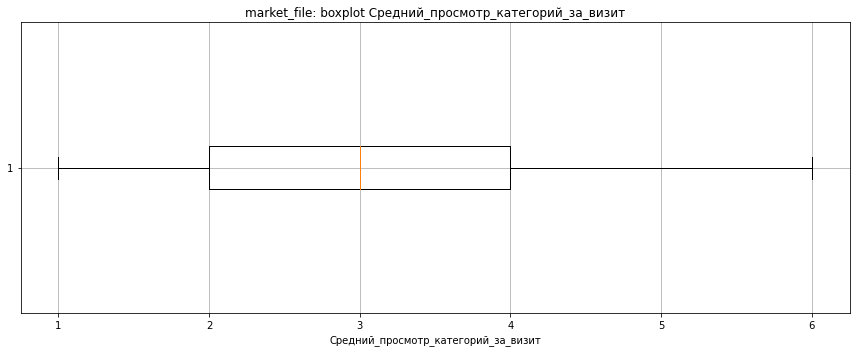

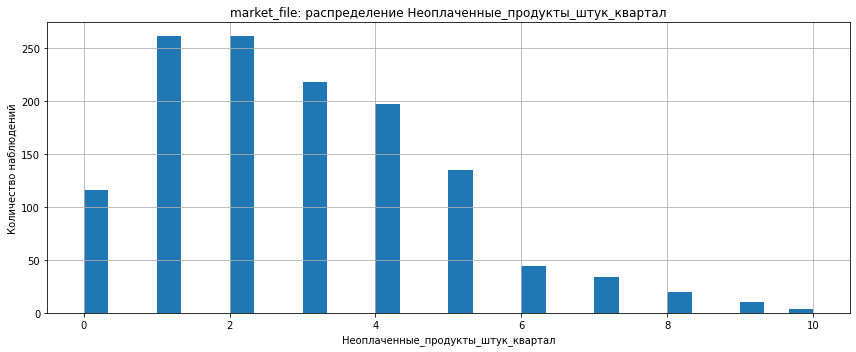

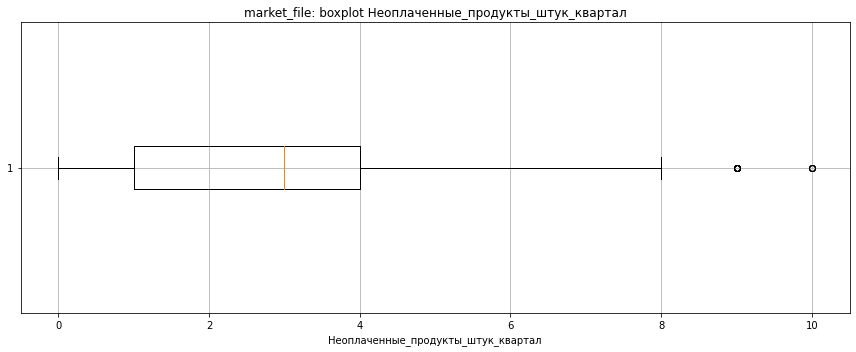

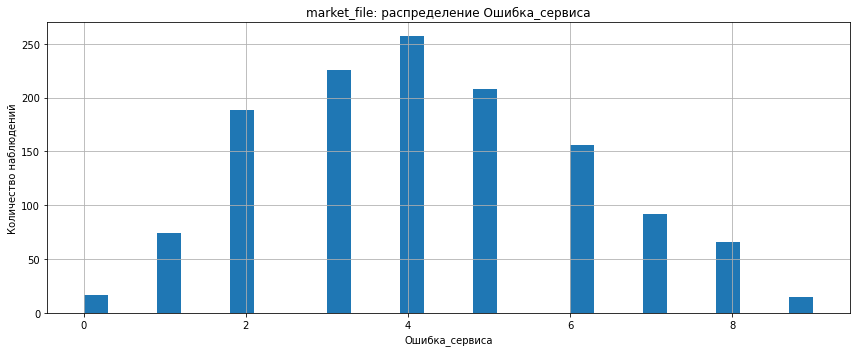

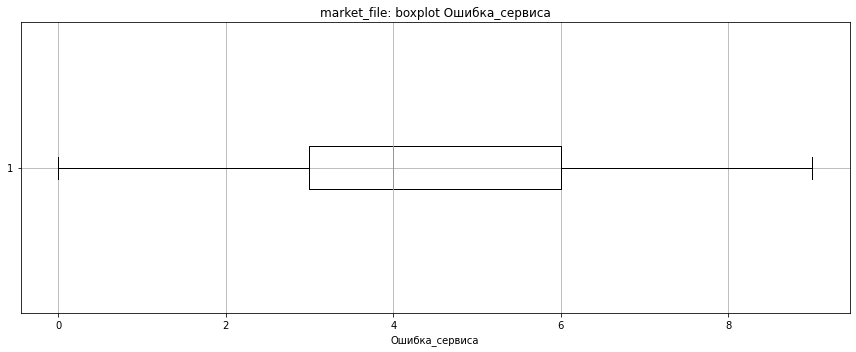

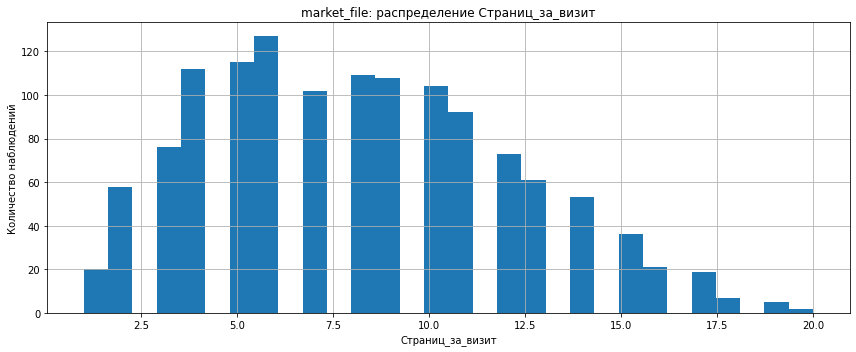

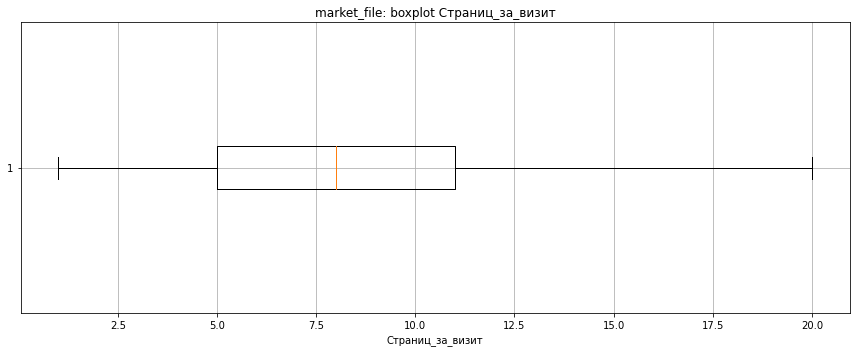

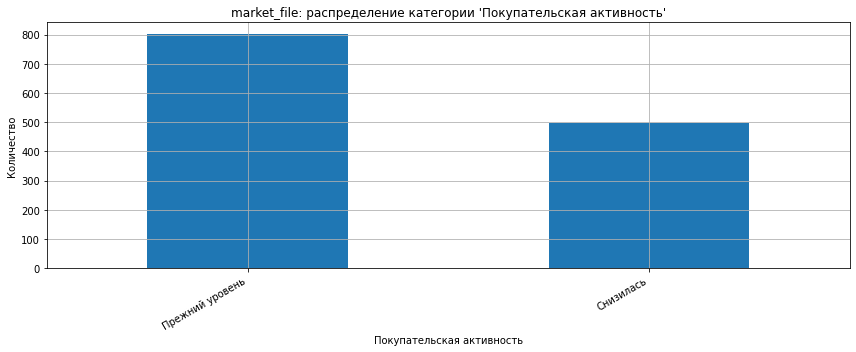

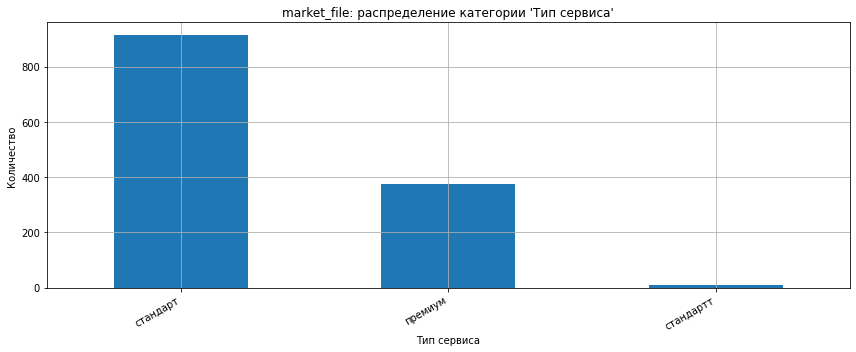

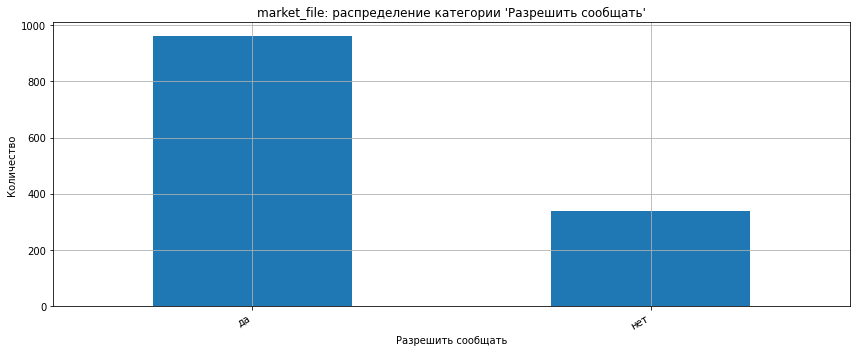

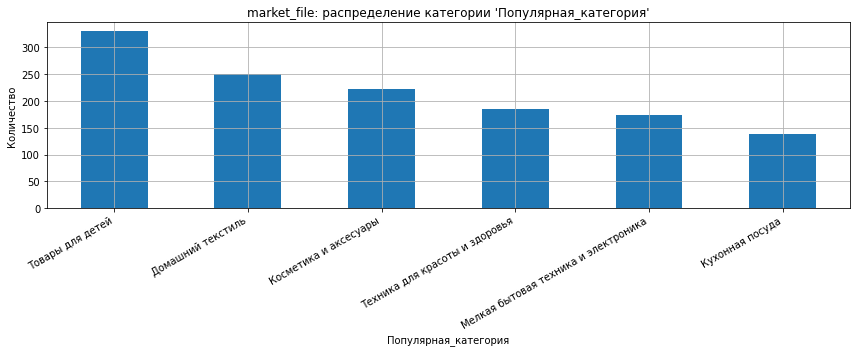

In [9]:
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# Проверка качества данных
print("market_file — пропуски:\n", market_file.isna().sum())
print("market_file — дубликаты:", market_file.duplicated().sum())

num_cols = market_file.select_dtypes(include=[np.number]).columns.tolist()
display(market_file[num_cols].describe().T)

for col in num_cols:
    # Гистограмма
    plt.figure()
    plt.hist(market_file[col], bins=30)
    plt.title(f"market_file: распределение {col}")
    plt.xlabel(col)
    plt.ylabel("Количество наблюдений")
    plt.tight_layout()
    plt.show()

    # Boxplot
    plt.figure()
    plt.boxplot(market_file[col], vert=False)
    plt.title(f"market_file: boxplot {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

cat_cols = market_file.select_dtypes(include=["object"]).columns.tolist()

for col in cat_cols:
    vc = market_file[col].value_counts()

    plt.figure()
    vc.plot(kind="bar")
    plt.title(f"market_file: распределение категории '{col}'")
    plt.xlabel(col)
    plt.ylabel("Количество")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

В файле market_file обнаружена ошибка в "Типе сервиса".

стандарт    924
премиум     376
Name: Тип сервиса, dtype: int64

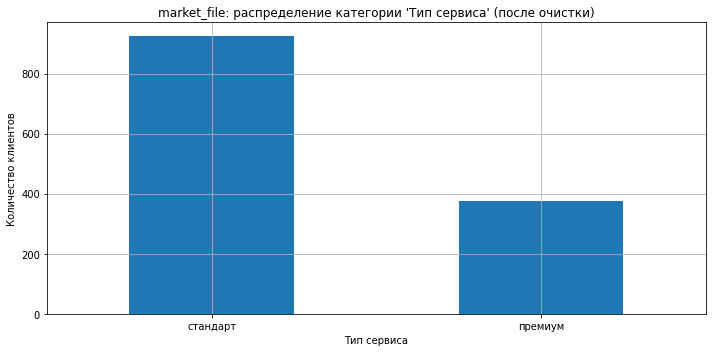

In [10]:
# Исправление опечатки в признаке "Тип сервиса"
market_file["Тип сервиса"] = market_file["Тип сервиса"].replace({
    "стандартт": "стандарт"
})

# Проверка результата
display(market_file["Тип сервиса"].value_counts())

plt.figure(figsize=(10, 5))
market_file["Тип сервиса"].value_counts().plot(kind="bar")
plt.title("market_file: распределение категории 'Тип сервиса' (после очистки)")
plt.xlabel("Тип сервиса")
plt.ylabel("Количество клиентов")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Объединение таблиц и разворот по периодам

In [21]:
anomaly_id = int(anomaly_rows["id"].iloc[0])

# Pivot по выручке (ТОЛЬКО очищенные данные)
money_wide = (market_money_clean
              .pivot_table(index="id", columns="Период", values="Выручка", aggfunc="sum")
              .fillna(0)
              .reset_index())
money_wide.columns = ["id"] + [f"Выручка_{c}" for c in money_wide.columns[1:]]

# Отбор клиентов с покупками во всех 3 месяцах
rev_cols = [c for c in money_wide.columns if c.startswith("Выручка_")]
active_mask = (money_wide[rev_cols] > 0).sum(axis=1) == 3
money_active = money_wide.loc[active_mask].copy()

# Удаляем клиента с аномалией
money_active = money_active[money_active["id"] != anomaly_id].copy()

print("Активных клиентов после фильтра:", money_active.shape[0])

# Pivot по времени
time_wide = (market_time
             .pivot_table(index="id", columns="Период", values="минут", aggfunc="sum")
             .reset_index())
time_wide.columns = ["id"] + [f"Минут_{c}" for c in time_wide.columns[1:]]

# Итоговая таблица
data_model = (market_file
              .merge(money_active, on="id", how="inner")
              .merge(time_wide, on="id", how="left"))

print("Итоговая таблица data_model:", data_model.shape)
assert data_model.shape[0] == 1296, f"Ожидалось 1296 строк, получено {data_model.shape[0]}"

display(data_model.head())


Активных клиентов после фильтра: 1296
Итоговая таблица data_model: (1296, 18)


,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Выручка_предыдущий_месяц,Выручка_препредыдущий_месяц,Выручка_текущий_месяц,Минут_предыдущий_месяц,Минут_текущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,10,10


# Отбор активных клиентов + корреляционный анализ

Итоговая таблица (до отбора активных): (1300, 18)


,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Выручка_предыдущий_месяц,Выручка_препредыдущий_месяц,Выручка_текущий_месяц,Минут_предыдущий_месяц,Минут_текущий_месяц
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5,0.0,0.0,3293.1,13,14
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11


После отбора активных клиентов: (1296, 18) | Исключено: 4
Сильные корреляции (Spearman |corr|>=0.9): 0


,feat_1,feat_2,rho


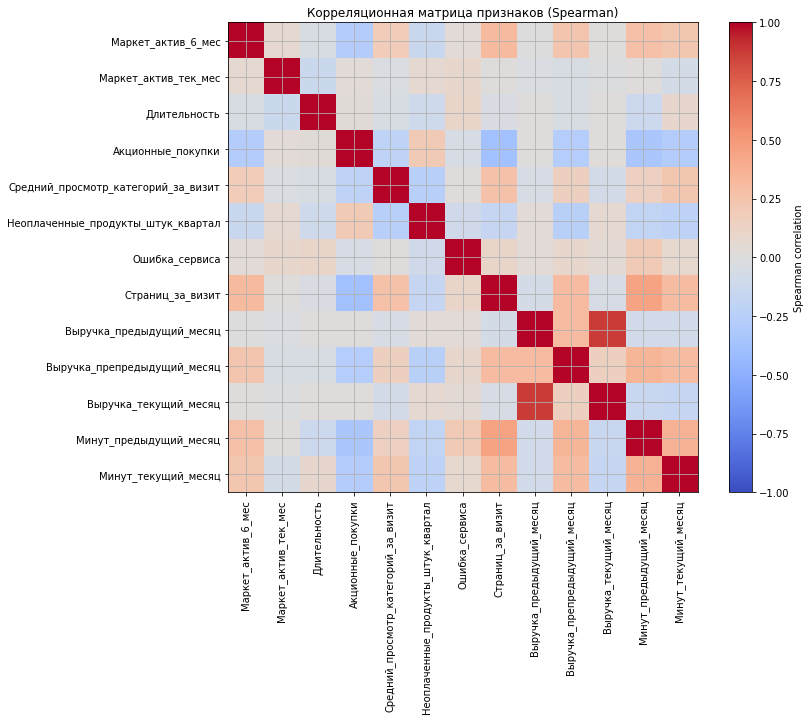

In [26]:
anomaly_id = int(anomaly_rows["id"].iloc[0])

money_wide = (market_money_clean
              .pivot_table(index="id", columns="Период", values="Выручка", aggfunc="sum")
              .fillna(0)
              .reset_index())
money_wide.columns = ["id"] + [f"Выручка_{c}" for c in money_wide.columns[1:]]

time_wide = (market_time
             .pivot_table(index="id", columns="Период", values="минут", aggfunc="sum")
             .reset_index())
time_wide.columns = ["id"] + [f"Минут_{c}" for c in time_wide.columns[1:]]

data = (market_file
        .merge(money_wide, on="id", how="left")
        .merge(time_wide, on="id", how="left"))

print("Итоговая таблица (до отбора активных):", data.shape)
display(data.head())

rev_cols = [c for c in data.columns if c.startswith("Выручка_")]
active_mask = (data[rev_cols].fillna(0) > 0).sum(axis=1) == 3

data_model = data.loc[active_mask & (data["id"] != anomaly_id)].copy()

print("После отбора активных клиентов:", data_model.shape,
      "| Исключено:", data.shape[0] - data_model.shape[0])

assert data_model.shape[0] == 1296, f"Ожидалось 1296 строк, получено {data_model.shape[0]}"
assert data_model["id"].nunique() == 1296, "Есть дубликаты id — проверь merge."

num_cols = data_model.select_dtypes(include=[np.number]).columns.tolist()
if "id" in num_cols:
    num_cols.remove("id")

corr_spearman = data_model[num_cols].corr(method="spearman")

thr = 0.90
high_corr_pairs = []
for i, c1 in enumerate(num_cols):
    for j in range(i + 1, len(num_cols)):
        c2 = num_cols[j]
        v = corr_spearman.loc[c1, c2]
        if abs(v) >= thr:
            high_corr_pairs.append((c1, c2, v))

print(f"Сильные корреляции (Spearman |corr|>={thr}):", len(high_corr_pairs))
display(pd.DataFrame(high_corr_pairs, columns=["feat_1", "feat_2", "rho"])
        .sort_values("rho", ascending=False)
        .head(20))

plt.figure(figsize=(12, 10))
plt.imshow(corr_spearman, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Spearman correlation")
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Корреляционная матрица признаков (Spearman)")
plt.tight_layout()
plt.show()

Корреляционная матрица Спирмана показала отсутствие выраженной
мультиколлинеарности между числовыми признаками: пар с коэффициентом
корреляции |ρ| ≥ 0.9 выявлено не было.

При этом наблюдаются логичные умеренные зависимости между показателями
вовлечённости на сайте (страницы и минуты) и между финансовыми
показателями по соседним месяцам. Поведенческие признаки, такие как
неоплаченные товары и ошибки сервиса, имеют слабые корреляции с
финансовыми метриками, что делает их потенциальными ранними индикаторами
снижения покупательской активности.

Полученные результаты позволяют использовать все признаки в дальнейшем
моделировании без их исключения.

Итоговая таблица размером 1296×18 содержит единый набор признаков,
характеризующих поведение клиентов с точки зрения коммуникаций,
продуктовых предпочтений, вовлечённости на сайте и финансовой активности.
Наличие временных финансовых и поведенческих признаков позволяет учитывать
динамику поведения клиента, что является ключевым для прогнозирования
снижения покупательской активности.

In [27]:
data_model.shape

(1296, 18)

In [28]:
data_model.Выручка_текущий_месяц.max()

7799.4

# Пайплайны и обучение 4 моделей

Категориальные: ['Тип сервиса', 'Разрешить сообщать', 'Популярная_категория']
  бинарные: ['Тип сервиса', 'Разрешить сообщать']
  многокатегориальные: ['Популярная_категория']
Числовые: 13
Лучшая модель по CV: KNeighborsClassifier(n_neighbors=25, weights='distance')
Лучший ROC-AUC (CV): 0.9152643809098354
Лучшие параметры:
 {'model': KNeighborsClassifier(n_neighbors=25, weights='distance'), 'model__n_neighbors': 25, 'model__weights': 'distance', 'preprocess__num__scaler': StandardScaler()}

TEST ROC-AUC: 0.9255349269910611
TEST F1: 0.8888888888888888

Classification report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94       201
           1       0.98      0.81      0.89       123

    accuracy                           0.92       324
   macro avg       0.94      0.90      0.91       324
weighted avg       0.93      0.92      0.92       324



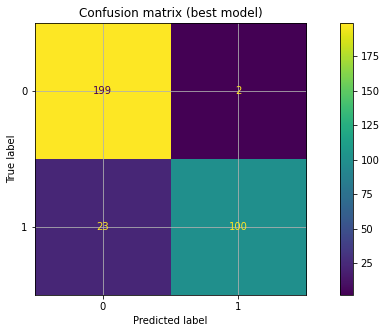

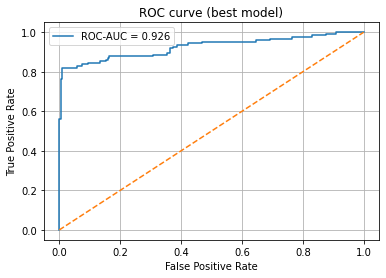

In [29]:
target_col = "Покупательская активность"
y = (data_model[target_col].str.lower() == "снизилась").astype(int)
X = data_model.drop(columns=[target_col, "id"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Разделим категориальные на бинарные (можно OE) и многокатегориальные (только OHE)
binary_cat_cols = [c for c in cat_cols if X_train[c].nunique(dropna=False) <= 2]
multi_cat_cols  = [c for c in cat_cols if c not in binary_cat_cols]

print("Категориальные:", cat_cols)
print("  бинарные:", binary_cat_cols)
print("  многокатегориальные:", multi_cat_cols)
print("Числовые:", len(num_cols))


num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())  # будет подбираться в GridSearchCV
])

# Ordinal для бинарных (да/нет, премиум/стандарт) — корректно, т.к. 2 значения
bin_cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

# OHE для многокатегориальных (в т.ч. "Популярная_категория") — ОБЯЗАТЕЛЬНО для LR/KNN/SVC
# sparse=False чтобы KNN точно работал (в старых sklearn параметр называется sparse)
ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

multi_cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", ohe)
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("bin_cat", bin_cat_pipe, binary_cat_cols),
        ("multi_cat", multi_cat_pipe, multi_cat_cols),
    ],
    remainder="drop"
)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=3000, random_state=42))  # будет заменяться в GridSearch
])

param_grid = [
    # Logistic Regression
    {
        "preprocess__num__scaler": [StandardScaler(), MinMaxScaler()],
        "model": [LogisticRegression(max_iter=3000, random_state=42)],
        "model__C": [0.1, 1, 10],
        "model__solver": ["lbfgs"],
    },
    # KNN
    {
        "preprocess__num__scaler": [StandardScaler(), MinMaxScaler()],
        "model": [KNeighborsClassifier()],
        "model__n_neighbors": [5, 10, 15, 25],
        "model__weights": ["uniform", "distance"],
    },
    # SVC
    {
        "preprocess__num__scaler": [StandardScaler(), MinMaxScaler()],
        "model": [SVC(probability=True, random_state=42)],
        "model__C": [0.5, 1, 5, 10],
        "model__kernel": ["rbf", "linear"],
        # gamma актуален для rbf; для linear игнорируется
        "model__gamma": ["scale", "auto"],
    },
    # Decision Tree
    {
        "preprocess__num__scaler": [StandardScaler(), MinMaxScaler()],  # дереву не обязательно, но не мешает
        "model": [DecisionTreeClassifier(random_state=42)],
        "model__max_depth": [3, 5, 8, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
    },
]

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="roc_auc",   # аргументация: важны вероятности и ранжирование риска
    cv=5,
    n_jobs=-1,
    refit=True,
    verbose=0
)

grid.fit(X_train, y_train)

print("Лучшая модель по CV:", grid.best_estimator_.named_steps["model"])
print("Лучший ROC-AUC (CV):", grid.best_score_)
print("Лучшие параметры:\n", grid.best_params_)

best_model = grid.best_estimator_
best_proba = best_model.predict_proba(X_test)[:, 1]
best_pred = (best_proba >= 0.5).astype(int)

print("\nTEST ROC-AUC:", roc_auc_score(y_test, best_proba))
print("TEST F1:", f1_score(y_test, best_pred))
print("\nClassification report:\n", classification_report(y_test, best_pred))

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion matrix (best model)")
plt.show()

fpr, tpr, _ = roc_curve(y_test, best_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, best_proba):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (best model)")
plt.legend()
plt.grid(True)
plt.show()

По результатам подбора гиперпараметров с использованием кросс-валидации
лучшей моделью по метрике ROC-AUC стала модель KNeighborsClassifier
с параметрами n_neighbors=25 и weights='distance'. Категориальные: ['Тип сервиса', 'Разрешить сообщать', 'Популярная_категория']
  бинарные: ['Разрешить сообщать']
  многокатегориальные: ['Тип сервиса', 'Популярная_категория']
Числовые: 13
Лучшая модель по CV: KNeighborsClassifier(n_neighbors=25, weights='distance')
Лучший ROC-AUC (CV): 0.9217655324746235
Лучшие параметры:
 {'model': KNeighborsClassifier(n_neighbors=25, weights='distance'), 'model__n_neighbors': 25, 'model__weights': 'distance', 'preprocess__num__scaler': StandardScaler()}

Выбор модели осуществлялся исключительно на обучающей выборке в рамках
кросс-валидации, что позволяет избежать подстройки под тестовые данные.

In [30]:
!pip install shap
import shap

X_train_trans shape: (972, 21)
X_test_trans  shape: (324, 21)
feature_names len: 21


  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_31/3662949666.py:51: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


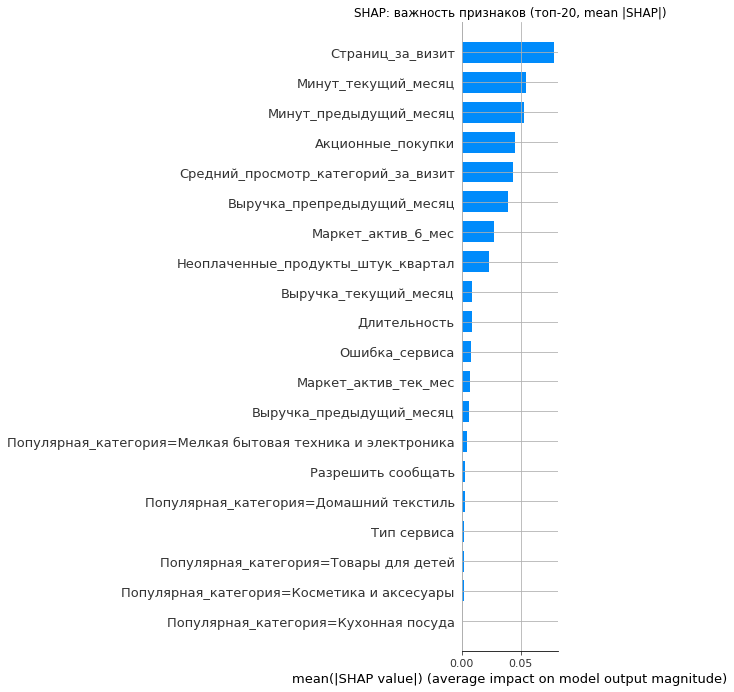

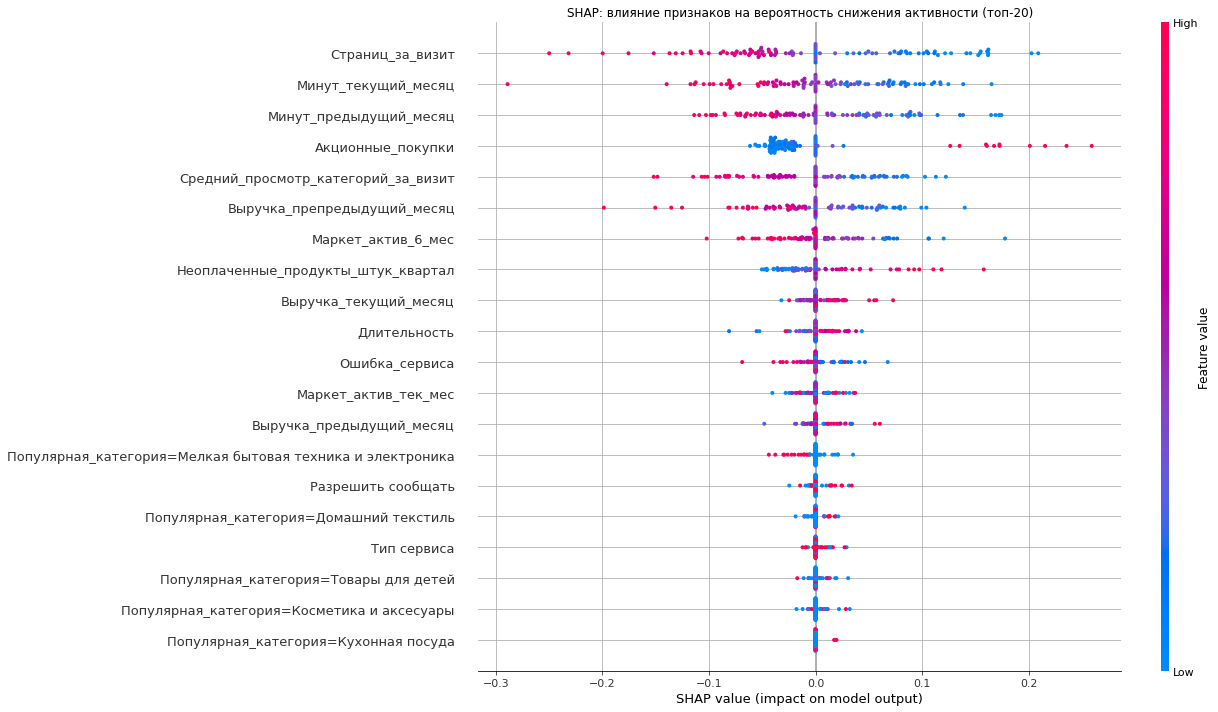

In [31]:
pre = best_model.named_steps["preprocess"]
clf = best_model.named_steps["model"]

X_train_trans = pre.transform(X_train)
X_test_trans  = pre.transform(X_test)

def get_feature_names_from_preprocess(preprocessor, num_cols, binary_cat_cols, multi_cat_cols):
    feature_names = []
    feature_names.extend(num_cols)
    feature_names.extend(binary_cat_cols)

    multi_pipe = preprocessor.named_transformers_["multi_cat"]
    ohe = multi_pipe.named_steps["encoder"]
    for col, cats in zip(multi_cat_cols, ohe.categories_):
        feature_names.extend([f"{col}={c}" for c in cats])

    return np.array(feature_names, dtype=object)

feature_names = get_feature_names_from_preprocess(pre, num_cols, binary_cat_cols, multi_cat_cols)

print("X_train_trans shape:", X_train_trans.shape)
print("X_test_trans  shape:", X_test_trans.shape)
print("feature_names len:", len(feature_names))

rng = np.random.RandomState(42)

bg_k = min(50, X_train_trans.shape[0])     # background summary size
X_bg = shap.kmeans(X_train_trans, bg_k)    # сжатие background через kmeans

expl_n = min(100, X_test_trans.shape[0])   # сколько объектов объясняем
expl_idx = rng.choice(X_test_trans.shape[0], size=expl_n, replace=False)
X_explain = X_test_trans[expl_idx]

def predict_proba_class1(X):
    return clf.predict_proba(X)[:, 1]

explainer = shap.KernelExplainer(predict_proba_class1, X_bg)
shap_values = explainer.shap_values(X_explain, nsamples=150)

max_disp = 20

plt.figure(figsize=(18, 10))
shap.summary_plot(
    shap_values, X_explain,
    feature_names=feature_names,
    plot_type="bar",
    max_display=max_disp,
    show=False
)
plt.title(f"SHAP: важность признаков (топ-{max_disp}, mean |SHAP|)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 10))
shap.summary_plot(
    shap_values, X_explain,
    feature_names=feature_names,
    max_display=max_disp,
    plot_size=None,   # чтобы shap не переопределял размер
    show=False
)
plt.title(f"SHAP: влияние признаков на вероятность снижения активности (топ-{max_disp})")
plt.tight_layout()
plt.show()

Полученные результаты позволяют использовать модель для проактивного
удержания клиентов. Снижение вовлечённости на сайте и рост доли акционных
покупок могут служить триггерами для персонализированных предложений,
упрощения пользовательского пути и адресных коммуникаций до того, как
произойдёт фактическое снижение покупательской активности.

# Сегментация клиентов по риску и прибыли

In [32]:
# Вероятность снижения активности для всех клиентов из data_model
X_all = data_model.drop(columns=[target_col, "id"])
proba_all = best_model.predict_proba(X_all)[:, 1]

seg = data_model[["id"]].copy()
seg["proba_drop"] = proba_all

# Добавим прибыль
seg = seg.merge(money, on="id", how="left")

display(seg.head())
display(seg["Прибыль"].describe())

,id,proba_drop,Прибыль
0,215349,0.962610,4.16
1,215350,1.000000,3.13
2,215351,0.769305,4.87
3,215352,1.000000,4.21
4,215353,0.726604,3.95


count    1296.000000
mean        3.997701
std         1.011198
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: Прибыль, dtype: float64

In [33]:
# Сегмент HighRisk–HighProfit:
# риск >= 0.80, прибыль >= 75 перцентиля
risk_thr = 0.80
profit_thr = seg["Прибыль"].quantile(0.75)

segment = seg[(seg["proba_drop"] >= risk_thr) & (seg["Прибыль"] >= profit_thr)].copy()
print("Порог прибыли (75%):", round(profit_thr, 2))
print("Размер сегмента:", segment.shape[0])

# Объединим обратно для анализа
full = data_model.merge(seg[["id", "proba_drop", "Прибыль"]], on="id", how="left")
segment_full = full[full["id"].isin(segment["id"])].copy()
rest_full = full[~full["id"].isin(segment["id"])].copy()

cols_compare = [
    "Неоплаченные_продукты_штук_квартал",
    "Акционные_покупки",
    "Страниц_за_визит",
    "Средний_просмотр_категорий_за_визит",
    "Минут_текущий_месяц",
    "Минут_предыдущий_месяц",
    "Маркет_актив_6_мес",
]

compare = pd.DataFrame({
    "segment_mean": segment_full[cols_compare].mean(),
    "rest_mean": rest_full[cols_compare].mean()
})
compare["diff"] = compare["segment_mean"] - compare["rest_mean"]
display(compare)

display(segment_full["Популярная_категория"].value_counts().head(10))

Порог прибыли (75%): 4.67
Размер сегмента: 103


,segment_mean,rest_mean,diff
Неоплаченные_продукты_штук_квартал,3.699029,2.767812,0.931217
Акционные_покупки,0.406117,0.312640,0.093476
Страниц_за_визит,5.446602,8.424141,-2.977539
Средний_просмотр_категорий_за_визит,2.427184,3.340319,-0.913134
Минут_текущий_месяц,11.058252,13.396479,-2.338227
Минут_предыдущий_месяц,10.941748,13.689019,-2.747272
Маркет_актив_6_мес,3.661165,4.307795,-0.646630


Товары для детей                        31
Косметика и аксесуары                   27
Домашний текстиль                       16
Техника для красоты и здоровья          11
Кухонная посуда                         11
Мелкая бытовая техника и электроника     7
Name: Популярная_категория, dtype: int64

Сегмент HighRisk–HighProfit объединяет наиболее ценных для бизнеса
клиентов, у которых наблюдаются признаки снижения вовлечённости и
проблемы на этапе оформления покупки. Работа с данным сегментом имеет
наибольший потенциал экономического эффекта.

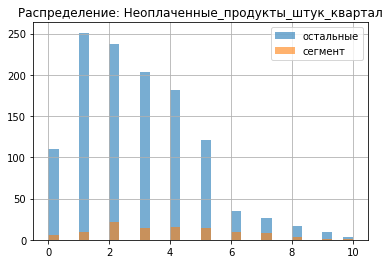

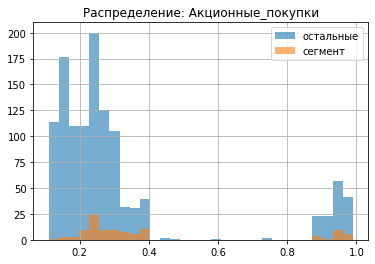

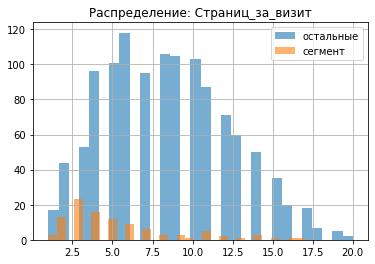

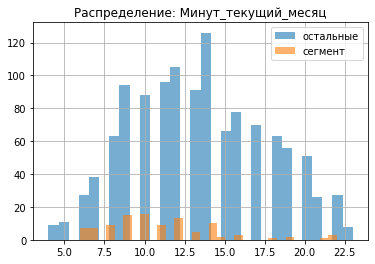

In [34]:
# Наглядные распределения по ключевым показателям
for c in ["Неоплаченные_продукты_штук_квартал", "Акционные_покупки", "Страниц_за_визит", "Минут_текущий_месяц"]:
    plt.figure(figsize=(6, 4))
    plt.hist(rest_full[c].dropna(), bins=30, alpha=0.6, label="остальные")
    plt.hist(segment_full[c].dropna(), bins=30, alpha=0.6, label="сегмент")
    plt.title(f"Распределение: {c}")
    plt.legend()
    plt.show()

# Промежуточный вывод

Построенные распределения наглядно подтверждают выявленные ранее
количественные различия между сегментом HighRisk–HighProfit и остальными
клиентами.

По числу неоплаченных товаров в корзине видно, что клиенты сегмента
существенно чаще имеют незавершённые покупки. Распределение сегмента
смещено вправо относительно остальных клиентов, что указывает на
повышенное трение на этапе оформления заказа.

Распределение доли акционных покупок показывает, что клиенты сегмента
значительно чаще совершают покупки по акциям. В сегменте заметна
концентрация значений в верхней части диапазона, что подтверждает
повышенную ценочувствительность данной группы.

В то же время показатели вовлечённости на сайте демонстрируют обратную
картину. Клиенты сегмента просматривают меньше страниц за визит и проводят
меньше времени на сайте в текущем месяце. Их распределения смещены влево
по сравнению с остальными клиентами, что свидетельствует о снижении
интереса или неудобстве взаимодействия с сайтом.

Таким образом, визуальный анализ подтверждает, что снижение активности у
наиболее прибыльных клиентов связано не с потерей ценности для бизнеса,
а с сочетанием ценочувствительности, падения вовлечённости и проблем на
этапе совершения покупки. Это делает сегмент HighRisk–HighProfit ключевым
приоритетом для точечных мер по удержанию.


## Персонализация для сегмента HighRisk–HighProfit

**1) Брошенная корзина / трение при оплате (главный рычаг)**
- триггер-цепочка: напоминание через 1–3 часа и повтор через 24 часа;
- упор на удобство: быстрые способы оплаты, сохранение корзины, «1 клик», автозаполнение.

**2) Уход от “скидочной зависимости”**
- вместо постоянных скидок: бандлы/комплекты, подарки, бесплатная доставка от порога;
- бандлы под топ-категории сегмента.

**3) Повышение вовлечённости**
- персональная витрина на главной;
- рекомендации «докупают вместе», «повторить заказ»;
- улучшение навигации и “короткий путь” к повторной покупке.

**4) Коммуникации строго по триггерам**
- не чаще 1 раза в неделю общие подборки;
- точечные триггеры: корзина/повтор покупки/новинки по любимой категории.